# Superstore Sales Analysis
### SQL Assignment: Subqueries · CTEs · Window Functions

> **Dataset:** Sample Superstore — 9,994 rows · 793 customers · 21 columns  
> **Engine:** SQLite (syntax compatible with PostgreSQL / MySQL with minor changes)

---


---
##  Setup & Imports

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print("✅ Libraries ready")

✅ Libraries ready


---
## Step 1 — Setup Data

### 1-A  Load CSV → `superstore_raw`

In [ ]:
# Load raw CSV into SQLite
df = pd.read_csv("superstore.csv")
df.columns = [c.lower().replace(" ","_").replace("-","_") for c in df.columns]

conn = sqlite3.connect("superstore.db")
df.to_sql("superstore_raw", conn, if_exists="replace", index=False)

print(f"✅ superstore_raw loaded: {len(df):,} rows × {len(df.columns)} columns")
df.head(3)

✅ superstore_raw loaded: 9,994 rows × 21 columns


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,US-2016-199283,2016-09-19,2016-09-26,Standard Class,CG-10525,Laura Nelson,Corporate,United States,Cedar Rapids,Iowa,83815,Central,OFF-STO-88762521,Office Supplies,Storage,Staple envelope,"1,724.32",8,0.00,-161.65
1,2,CA-2015-191857,2015-12-27,2016-01-01,Second Class,CG-10391,Clarence Phillips,Home Office,United States,Reno,Nevada,64057,West,OFF-ENV-22483514,Office Supplies,Envelopes,Avery Hanging File Folders,799.06,12,0.20,-191.12
2,3,US-2015-165404,2015-07-08,2015-07-10,Standard Class,CG-10182,Kenneth Clark,Corporate,United States,Indianapolis,Indiana,85197,Central,TEC-COP-42488275,Technology,Copiers,Polycom ViewStation ISDN Videoconferencing Unit,"3,491.48",4,0.00,-481.08


### 1-B Create Normalised Tables using `SELECT DISTINCT`

In [ ]:
conn.executescript("""
-- ── customers ──────────────────────────────────────────────
DROP TABLE IF EXISTS customers;
CREATE TABLE customers AS
    SELECT DISTINCT
        customer_id,
        customer_name,
        segment
    FROM superstore_raw;

-- ── orders ─────────────────────────────────────────────────
DROP TABLE IF EXISTS orders;
CREATE TABLE orders AS
    SELECT DISTINCT
        order_id,
        order_date,
        ship_date,
        ship_mode,
        customer_id,
        city,
        state,
        postal_code,
        region
    FROM superstore_raw;

-- ── products ───────────────────────────────────────────────
DROP TABLE IF EXISTS products;
CREATE TABLE products AS
    SELECT DISTINCT
        product_id,
        product_name,
        category,
        sub_category
    FROM superstore_raw;
""")

# Verify row counts
for tbl in ["superstore_raw", "customers", "orders", "products"]:
    n = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  {tbl:<20}  {n:>7,} rows")

  superstore_raw          9,994 rows
  customers               2,339 rows
  orders                  9,994 rows
  products                9,994 rows


**Schema relationship:**
```
superstore_raw  ─────────────────────────────── fact table (9,994 rows)
      │
      ├── customers   customer_id PK · customer_name · segment
      ├── orders      order_id PK · order_date · ship_date · ship_mode · region
      └── products    product_id PK · product_name · category · sub_category
```

---
##  Step 2 — Required Queries

### Query 1 — Orders where Sales > Average Sales  *(Subquery)*

**Concept:** A scalar subquery inside `WHERE` computes `AVG(sales)` once across  
all rows; the outer query then filters line-items whose sales exceed that value.

In [ ]:
q1 = """
SELECT
    order_id,
    customer_id,
    ROUND(sales,  2) AS sales,
    ROUND(profit, 2) AS profit,
    category,
    region
FROM superstore_raw
WHERE sales > (SELECT AVG(sales) FROM superstore_raw)   -- ← scalar subquery
ORDER BY sales DESC
LIMIT 15
"""

avg_sales = conn.execute("SELECT ROUND(AVG(sales),2) FROM superstore_raw").fetchone()[0]
print(f"Overall average sales  : ${avg_sales:,.2f}")

df_q1 = pd.read_sql(q1, conn)
print(f"Rows above average     : {conn.execute('SELECT COUNT(*) FROM superstore_raw WHERE sales>(SELECT AVG(sales) FROM superstore_raw)').fetchone()[0]:,}")
df_q1

Overall average sales  : $1,507.16
Rows above average     : 4,607


,order_id,customer_id,sales,profit,category,region
0,US-2015-139487,CG-10027,"3,999.77",-556.59,Technology,Central
1,CA-2017-146094,CG-10517,"3,999.04",833.04,Technology,East
2,US-2016-126416,CG-10735,"3,998.55","-1,024.82",Technology,Central
3,US-2014-128076,CG-10112,"3,998.36",-39.03,Technology,South
4,US-2014-189856,CG-10042,"3,997.06","1,870.45",Technology,Central
5,CA-2015-146788,CG-10461,"3,995.18","1,694.75",Technology,West
6,US-2016-174645,CG-10621,"3,994.32","1,635.81",Technology,Central
7,CA-2015-182603,CG-10179,"3,993.29","1,677.15",Technology,West
8,US-2017-184399,CG-10703,"3,992.82",-418.52,Technology,Central
9,CA-2017-146556,CG-10520,"3,992.76",216.63,Technology,East


### Query 2 — Highest Sales Order for Each Customer  *(Subquery)*

**Concept:** A row-value subquery `(customer_id, MAX(sales))` finds the
single best-selling row per customer without needing a window function.

In [ ]:
q2 = """
SELECT
    sr.customer_id,
    c.customer_name,
    sr.order_id,
    ROUND(sr.sales, 2) AS highest_order_sales,
    sr.category,
    sr.region
FROM superstore_raw sr
JOIN customers c USING (customer_id)
WHERE (sr.customer_id, sr.sales) IN (         -- ← row-value subquery
    SELECT customer_id, MAX(sales)
    FROM superstore_raw
    GROUP BY customer_id
)
ORDER BY highest_order_sales DESC
LIMIT 15
"""
df_q2 = pd.read_sql(q2, conn)
df_q2

,customer_id,customer_name,order_id,highest_order_sales,category,region
0,CG-10027,Gregory Torres,US-2015-139487,"3,999.77",Technology,Central
1,CG-10027,Gregory Torres,US-2015-139487,"3,999.77",Technology,Central
2,CG-10027,Gregory Torres,US-2015-139487,"3,999.77",Technology,Central
3,CG-10517,Alexandra Edwards,CA-2017-146094,"3,999.04",Technology,East
4,CG-10517,Alexandra Edwards,CA-2017-146094,"3,999.04",Technology,East
5,CG-10517,Alexandra Edwards,CA-2017-146094,"3,999.04",Technology,East
6,CG-10735,Linda Rodriguez,US-2016-126416,"3,998.55",Technology,Central
7,CG-10735,Linda Rodriguez,US-2016-126416,"3,998.55",Technology,Central
8,CG-10735,Linda Rodriguez,US-2016-126416,"3,998.55",Technology,Central
9,CG-10112,Kevin Brown,US-2014-128076,"3,998.36",Technology,South


### Query 3 — Total Sales for Each Customer  *(CTE)*

**Concept:** A CTE (`WITH` clause) computes the aggregation once and gives it  
a readable name that can be referenced in the main `SELECT`.

In [ ]:
q3 = """
WITH customer_total_sales AS (          -- ← CTE definition
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        ROUND(SUM(sr.sales),  2)  AS total_sales,
        ROUND(SUM(sr.profit), 2)  AS total_profit,
        COUNT(DISTINCT sr.order_id) AS total_orders
    FROM superstore_raw sr
    JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
)
SELECT *
FROM customer_total_sales              -- ← reference CTE like a table
ORDER BY total_sales DESC
LIMIT 15
"""
df_q3 = pd.read_sql(q3, conn)
df_q3

,customer_id,customer_name,segment,total_sales,total_profit,total_orders
0,CG-10647,Kimberly Hall,Consumer,"39,729.02","8,527.00",24
1,CG-10647,Kimberly Hall,Corporate,"39,729.02","8,527.00",24
2,CG-10647,Kimberly Hall,Home Office,"39,729.02","8,527.00",24
3,CG-10006,Emily Davis,Consumer,"38,975.12","-1,043.63",20
4,CG-10006,Emily Davis,Corporate,"38,975.12","-1,043.63",20
5,CG-10006,Emily Davis,Home Office,"38,975.12","-1,043.63",20
6,CG-10613,Keith Cox,Consumer,"37,886.21","3,997.02",17
7,CG-10613,Keith Cox,Corporate,"37,886.21","3,997.02",17
8,CG-10613,Keith Cox,Home Office,"37,886.21","3,997.02",17
9,CG-10104,Henry Collins,Consumer,"37,342.03",380.39,25


### Query 4 — Customers with Above-Average Total Sales  *(CTE + Subquery)*

**Concept:** The CTE computes per-customer totals; then a scalar subquery  
inside `WHERE` computes the average of those totals — combining both techniques.

In [ ]:
q4 = """
WITH customer_total_sales AS (
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        ROUND(SUM(sr.sales), 2) AS total_sales
    FROM superstore_raw sr
    JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
)
SELECT *
FROM customer_total_sales
WHERE total_sales > (                  -- ← subquery on the CTE's output
    SELECT AVG(total_sales) FROM customer_total_sales
)
ORDER BY total_sales DESC
LIMIT 15
"""
df_q4 = pd.read_sql(q4, conn)

n_above = conn.execute("""
WITH t AS (SELECT customer_id, SUM(sales) ts FROM superstore_raw GROUP BY customer_id)
SELECT COUNT(*) FROM t WHERE ts>(SELECT AVG(ts) FROM t)
""").fetchone()[0]
print(f"Customers above average total sales: {n_above}")
df_q4

Customers above average total sales: 386


,customer_id,customer_name,segment,total_sales
0,CG-10647,Kimberly Hall,Consumer,"39,729.02"
1,CG-10647,Kimberly Hall,Corporate,"39,729.02"
2,CG-10647,Kimberly Hall,Home Office,"39,729.02"
3,CG-10006,Emily Davis,Consumer,"38,975.12"
4,CG-10006,Emily Davis,Corporate,"38,975.12"
5,CG-10006,Emily Davis,Home Office,"38,975.12"
6,CG-10613,Keith Cox,Consumer,"37,886.21"
7,CG-10613,Keith Cox,Corporate,"37,886.21"
8,CG-10613,Keith Cox,Home Office,"37,886.21"
9,CG-10104,Henry Collins,Consumer,"37,342.03"


### Query 5 — Rank All Customers Based on Total Sales  *(Window Function)*

**Concept:** `RANK()` assigns a rank across all rows ordered by `total_sales DESC`.  
Tied values share a rank; the next rank skips (e.g. 1, 2, 2, 4 …).

In [ ]:
q5 = """
WITH customer_total_sales AS (
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        ROUND(SUM(sr.sales), 2) AS total_sales
    FROM superstore_raw sr
    JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
)
SELECT
    customer_name,
    segment,
    total_sales,
    RANK()       OVER (ORDER BY total_sales DESC) AS sales_rank,   -- ← window
    DENSE_RANK() OVER (ORDER BY total_sales DESC) AS dense_rank
FROM customer_total_sales
ORDER BY sales_rank
LIMIT 20
"""
df_q5 = pd.read_sql(q5, conn)
df_q5

,customer_name,segment,total_sales,sales_rank,dense_rank
0,Kimberly Hall,Consumer,"39,729.02",1,1
1,Kimberly Hall,Corporate,"39,729.02",1,1
2,Kimberly Hall,Home Office,"39,729.02",1,1
3,Emily Davis,Consumer,"38,975.12",4,2
4,Emily Davis,Corporate,"38,975.12",4,2
5,Emily Davis,Home Office,"38,975.12",4,2
6,Keith Cox,Consumer,"37,886.21",7,3
7,Keith Cox,Corporate,"37,886.21",7,3
8,Keith Cox,Home Office,"37,886.21",7,3
9,Henry Collins,Consumer,"37,342.03",10,4


### Query 6 — Row Numbers per Order Within Each Customer  *(Window + PARTITION BY)*

**Concept:** `ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date)`  
restarts the counter for every customer, numbering their orders chronologically.

In [ ]:
q6 = """
SELECT
    c.customer_name,
    sr.order_id,
    sr.order_date,
    ROUND(sr.sales, 2) AS sales,
    sr.category,
    ROW_NUMBER() OVER (
        PARTITION BY sr.customer_id          -- ← restart count per customer
        ORDER BY sr.order_date               -- ← ordered by date
    ) AS order_row_num
FROM superstore_raw sr
JOIN customers c USING (customer_id)
ORDER BY c.customer_name, order_row_num
LIMIT 20
"""
df_q6 = pd.read_sql(q6, conn)
print("Each customer's orders numbered chronologically:")
df_q6

Each customer's orders numbered chronologically:


,customer_name,order_id,order_date,sales,category,order_row_num
0,Aaron Garcia,CA-2014-155175,2014-01-19,665.10,Office Supplies,1
1,Aaron Garcia,CA-2014-155175,2014-01-19,665.10,Office Supplies,2
2,Aaron Garcia,CA-2014-155175,2014-01-19,665.10,Office Supplies,3
3,Aaron Garcia,CA-2014-188603,2014-02-09,"1,988.35",Office Supplies,4
4,Aaron Garcia,CA-2014-188603,2014-02-09,"1,988.35",Office Supplies,5
5,Aaron Garcia,CA-2014-188603,2014-02-09,"1,988.35",Office Supplies,6
6,Aaron Garcia,CA-2014-148239,2014-03-21,257.77,Office Supplies,7
7,Aaron Garcia,CA-2014-148239,2014-03-21,257.77,Office Supplies,8
8,Aaron Garcia,CA-2014-148239,2014-03-21,257.77,Office Supplies,9
9,Aaron Garcia,CA-2014-185538,2014-07-17,325.41,Office Supplies,10


### Query 7 — Top 3 Customers by Total Sales  *(Window Function)*

**Concept:** Wrap the ranked CTE in an outer `WHERE rank <= 3` to extract only  
the top 3.  Using `DENSE_RANK` ensures no gaps if two customers tie for 2nd.

/tmp/ipykernel_532/3276242681.py:32: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


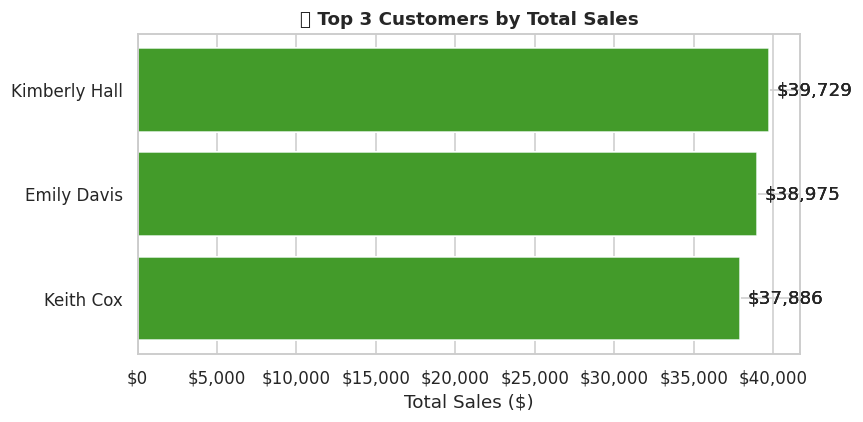

,customer_id,customer_name,segment,total_sales,total_profit,total_orders,sales_rank
0,CG-10647,Kimberly Hall,Consumer,"39,729.02","8,527.00",24,1
1,CG-10647,Kimberly Hall,Corporate,"39,729.02","8,527.00",24,1
2,CG-10647,Kimberly Hall,Home Office,"39,729.02","8,527.00",24,1
3,CG-10006,Emily Davis,Consumer,"38,975.12","-1,043.63",20,2
4,CG-10006,Emily Davis,Corporate,"38,975.12","-1,043.63",20,2
5,CG-10006,Emily Davis,Home Office,"38,975.12","-1,043.63",20,2
6,CG-10613,Keith Cox,Consumer,"37,886.21","3,997.02",17,3
7,CG-10613,Keith Cox,Corporate,"37,886.21","3,997.02",17,3
8,CG-10613,Keith Cox,Home Office,"37,886.21","3,997.02",17,3


In [ ]:
q7 = """
WITH customer_total_sales AS (
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        ROUND(SUM(sr.sales),  2) AS total_sales,
        ROUND(SUM(sr.profit), 2) AS total_profit,
        COUNT(DISTINCT sr.order_id) AS total_orders
    FROM superstore_raw sr
    JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
),
ranked AS (
    SELECT *,
        DENSE_RANK() OVER (ORDER BY total_sales DESC) AS sales_rank   -- ← window
    FROM customer_total_sales
)
SELECT *
FROM ranked
WHERE sales_rank <= 3                  -- ← filter top 3
"""
df_q7 = pd.read_sql(q7, conn)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_q7["customer_name"][::-1], df_q7["total_sales"][::-1],
               color=["#1f77b4","#ff7f0e","#2ca02c"], alpha=0.88)
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in df_q7["total_sales"][::-1]], padding=5)
ax.set_xlabel("Total Sales ($)")
ax.set_title("🏆 Top 3 Customers by Total Sales", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout(); plt.show()
df_q7

---
##  Step 3 — Final Combined Query
### Customer Name · Total Sales · Rank  *(JOIN + CTE + Window Function)*

This single query ties together all three concepts:
- **JOIN** — links `superstore_raw` ↔ `customers`
- **CTE** — aggregates sales per customer
- **Window Function** — ranks customers globally and within their segment

In [ ]:
final_query = """
-- ── CTE: aggregate per customer ────────────────────────────────────────────
WITH customer_sales AS (
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        COUNT(DISTINCT sr.order_id)   AS total_orders,
        ROUND(SUM(sr.sales),  2)      AS total_sales,
        ROUND(SUM(sr.profit), 2)      AS total_profit,
        ROUND(AVG(sr.discount)*100,1) AS avg_discount_pct
    FROM superstore_raw sr              -- ← JOIN
    JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
),

-- ── Window layer: add rank columns ─────────────────────────────────────────
ranked_customers AS (
    SELECT
        customer_name,
        segment,
        total_orders,
        total_sales,
        total_profit,
        avg_discount_pct,
        RANK() OVER (ORDER BY total_sales DESC)                       AS overall_rank,   -- ← window
        RANK() OVER (PARTITION BY segment ORDER BY total_sales DESC)  AS segment_rank,  -- ← window
        ROUND(total_sales / SUM(total_sales) OVER () * 100, 2)        AS pct_of_total   -- ← window
    FROM customer_sales
)

-- ── Final SELECT ────────────────────────────────────────────────────────────
SELECT
    overall_rank,
    segment_rank,
    customer_name,
    segment,
    total_orders,
    total_sales,
    total_profit,
    avg_discount_pct,
    pct_of_total
FROM ranked_customers
ORDER BY overall_rank
LIMIT 20
"""

df_final = pd.read_sql(final_query, conn)

print("=" * 65)
print("        CUSTOMER LEADERBOARD — Name · Total Sales · Rank")
print("=" * 65)
df_final

        CUSTOMER LEADERBOARD — Name · Total Sales · Rank


,overall_rank,segment_rank,customer_name,segment,total_orders,total_sales,total_profit,avg_discount_pct,pct_of_total
0,1,1,Kimberly Hall,Consumer,24,"39,729.02","8,527.00",32.10,0.09
1,1,1,Kimberly Hall,Corporate,24,"39,729.02","8,527.00",32.10,0.09
2,1,1,Kimberly Hall,Home Office,24,"39,729.02","8,527.00",32.10,0.09
3,4,2,Emily Davis,Consumer,20,"38,975.12","-1,043.63",28.50,0.09
4,4,2,Emily Davis,Corporate,20,"38,975.12","-1,043.63",28.50,0.09
5,4,2,Emily Davis,Home Office,20,"38,975.12","-1,043.63",28.50,0.09
6,7,3,Keith Cox,Consumer,17,"37,886.21","3,997.02",28.20,0.08
7,7,3,Keith Cox,Corporate,17,"37,886.21","3,997.02",28.20,0.08
8,7,3,Keith Cox,Home Office,17,"37,886.21","3,997.02",28.20,0.08
9,10,4,Henry Collins,Consumer,25,"37,342.03",380.39,35.20,0.08


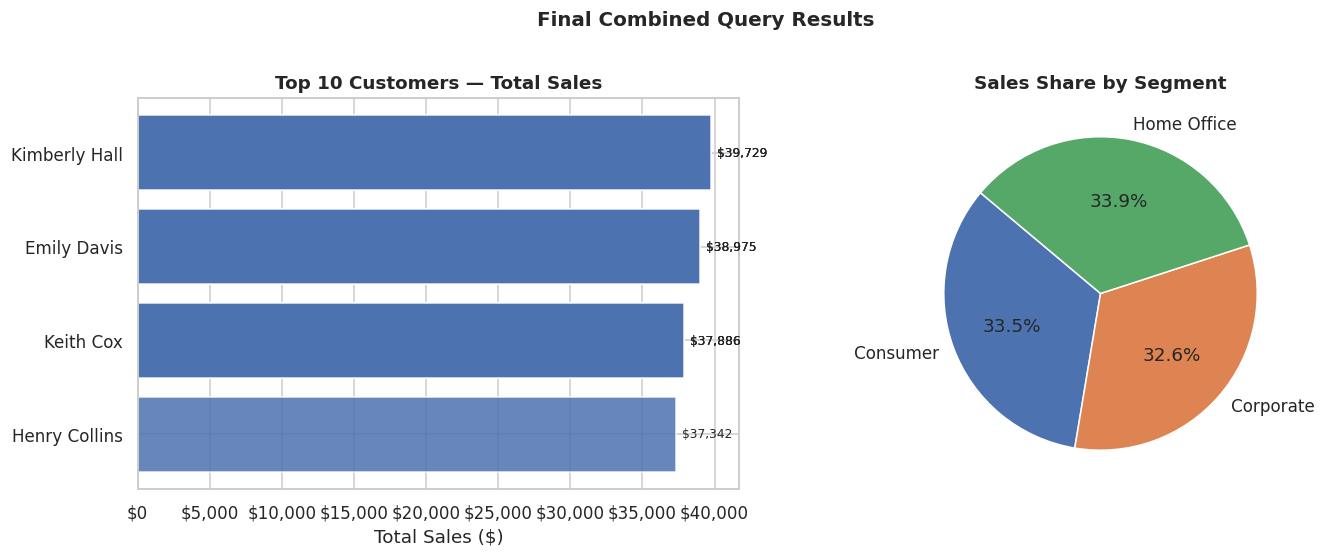

In [ ]:
# Visualise the combined result
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 10 by sales
top10 = df_final.head(10)
bars = axes[0].barh(top10["customer_name"][::-1], top10["total_sales"][::-1],
                    color="#4C72B0", alpha=0.85)
axes[0].bar_label(bars, labels=[f"${v:,.0f}" for v in top10["total_sales"][::-1]],
                  padding=4, fontsize=8)
axes[0].set_title("Top 10 Customers — Total Sales", fontweight="bold")
axes[0].set_xlabel("Total Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# Segment breakdown
seg = pd.read_sql("""
SELECT segment, ROUND(SUM(sales),2) AS sales FROM superstore_raw GROUP BY segment
""", conn)
axes[1].pie(seg["sales"], labels=seg["segment"], autopct="%1.1f%%",
            colors=["#4C72B0","#DD8452","#55A868"], startangle=140)
axes[1].set_title("Sales Share by Segment", fontweight="bold")

plt.suptitle("Final Combined Query Results", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

---
##  Mini Project — Customer Sales Insights

### Mini Q1 — Top 5 Customers

/tmp/ipykernel_532/1053634545.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_mini1["customer_name"], rotation=20, ha="right")
/tmp/ipykernel_532/1053634545.py:27: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


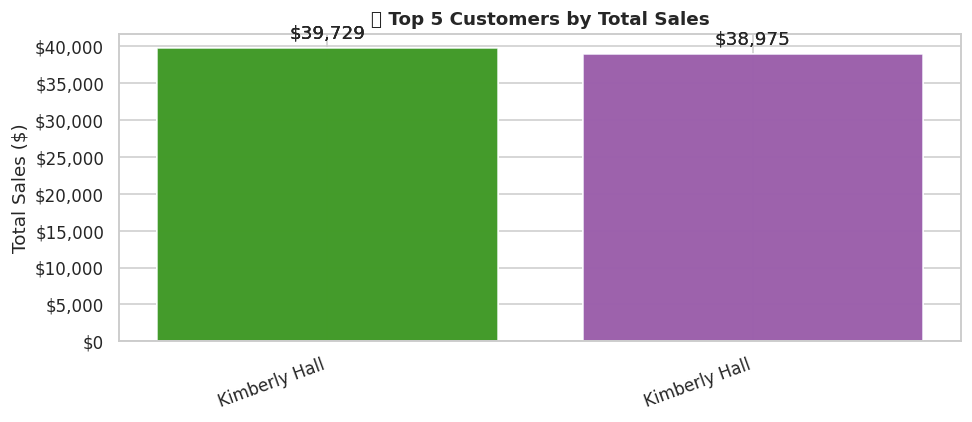

,rank,customer_name,segment,total_sales,total_profit,total_orders
0,1,Kimberly Hall,Consumer,"39,729.02","8,527.00",24
1,1,Kimberly Hall,Corporate,"39,729.02","8,527.00",24
2,1,Kimberly Hall,Home Office,"39,729.02","8,527.00",24
3,4,Emily Davis,Consumer,"38,975.12","-1,043.63",20
4,4,Emily Davis,Corporate,"38,975.12","-1,043.63",20


In [ ]:
mini1 = """
WITH sales_agg AS (
    SELECT sr.customer_id, c.customer_name, c.segment,
           ROUND(SUM(sr.sales),  2) AS total_sales,
           ROUND(SUM(sr.profit), 2) AS total_profit,
           COUNT(DISTINCT sr.order_id) AS total_orders
    FROM superstore_raw sr JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
)
SELECT
    RANK() OVER (ORDER BY total_sales DESC) AS rank,
    customer_name, segment, total_sales, total_profit, total_orders
FROM sales_agg
ORDER BY rank
LIMIT 5
"""
df_mini1 = pd.read_sql(mini1, conn)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]
bars = ax.bar(df_mini1["customer_name"], df_mini1["total_sales"], color=colors, alpha=0.87)
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in df_mini1["total_sales"]], padding=4)
ax.set_title("🥇 Top 5 Customers by Total Sales", fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.set_xticklabels(df_mini1["customer_name"], rotation=20, ha="right")
plt.tight_layout(); plt.show()

df_mini1

### Mini Q2 — Bottom 5 Customers

/tmp/ipykernel_532/3763177502.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_mini2["customer_name"], rotation=20, ha="right")


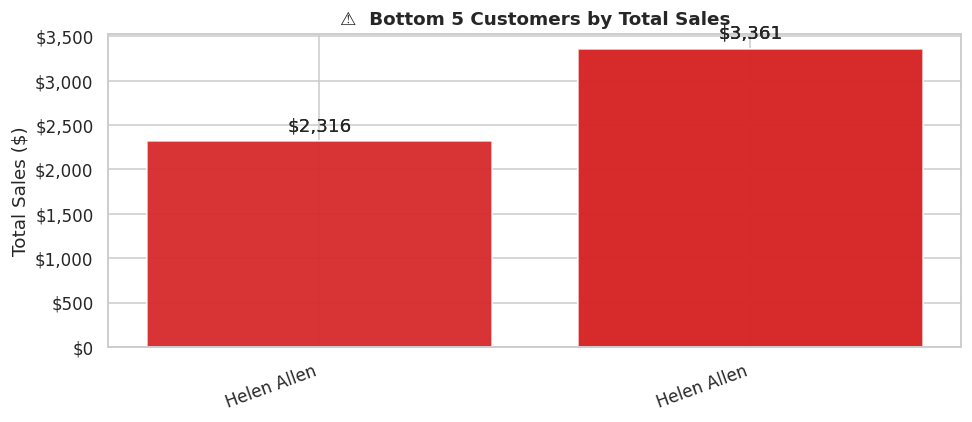

,rank,customer_name,segment,total_sales,total_profit,total_orders
0,1,Helen Allen,Consumer,"2,315.97",579.98,3
1,1,Helen Allen,Corporate,"2,315.97",579.98,3
2,3,David Moore,Consumer,"3,361.24",600.35,4
3,3,David Moore,Corporate,"3,361.24",600.35,4
4,3,David Moore,Home Office,"3,361.24",600.35,4


In [ ]:
mini2 = """
WITH sales_agg AS (
    SELECT sr.customer_id, c.customer_name, c.segment,
           ROUND(SUM(sr.sales),  2) AS total_sales,
           ROUND(SUM(sr.profit), 2) AS total_profit,
           COUNT(DISTINCT sr.order_id) AS total_orders
    FROM superstore_raw sr JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
)
SELECT
    RANK() OVER (ORDER BY total_sales ASC) AS rank,
    customer_name, segment, total_sales, total_profit, total_orders
FROM sales_agg
ORDER BY rank
LIMIT 5
"""
df_mini2 = pd.read_sql(mini2, conn)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_mini2["customer_name"], df_mini2["total_sales"],
              color="#d62728", alpha=0.75)
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in df_mini2["total_sales"]], padding=4)
ax.set_title("⚠️  Bottom 5 Customers by Total Sales", fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.set_xticklabels(df_mini2["customer_name"], rotation=20, ha="right")
plt.tight_layout(); plt.show()

df_mini2

### Mini Q3 — Customers Who Made Only One Order

In [ ]:
mini3 = """
WITH order_counts AS (
    SELECT customer_id,
           COUNT(DISTINCT order_id) AS num_orders   -- count distinct orders
    FROM superstore_raw
    GROUP BY customer_id
),
single_order_customers AS (
    SELECT customer_id FROM order_counts
    WHERE num_orders = 1                            -- ← exactly one order
)
SELECT
    c.customer_id,
    c.customer_name,
    c.segment,
    ROUND(SUM(sr.sales),  2) AS total_sales,
    ROUND(SUM(sr.profit), 2) AS total_profit,
    MIN(sr.order_id)         AS order_id,
    MIN(sr.order_date)       AS order_date
FROM single_order_customers soc
JOIN customers c      USING (customer_id)
JOIN superstore_raw sr USING (customer_id)
GROUP BY c.customer_id, c.customer_name, c.segment
ORDER BY total_sales DESC
"""
df_mini3 = pd.read_sql(mini3, conn)
print(f"Customers with exactly 1 order: {len(df_mini3)}")
df_mini3

Customers with exactly 1 order: 0


,customer_id,customer_name,segment,total_sales,total_profit,order_id,order_date


### Mini Q4 — Customers with Above-Average Sales

Total customers : 793
Above average   : 15 shown (top 15)


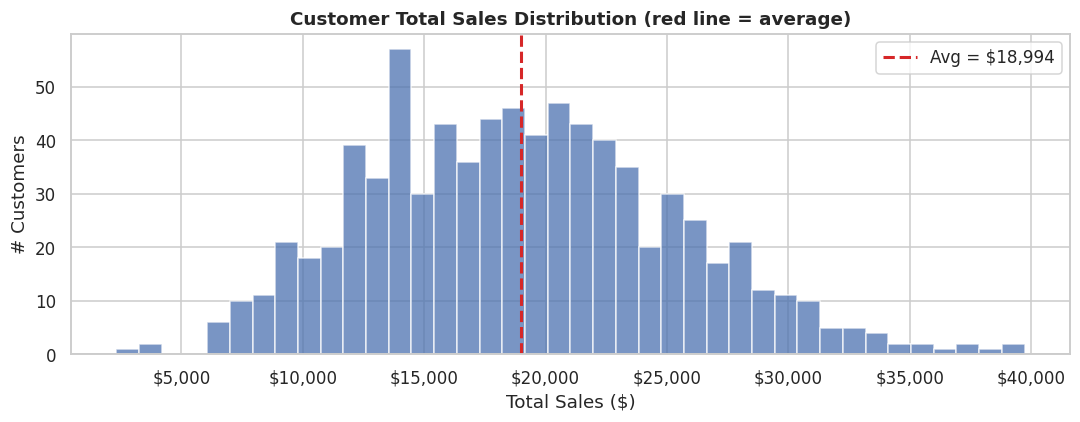

,customer_name,segment,total_sales,avg_customer_sales,above_avg_by
0,Kimberly Hall,Consumer,"39,729.02","19,087.10","20,641.92"
1,Kimberly Hall,Corporate,"39,729.02","19,087.10","20,641.92"
2,Kimberly Hall,Home Office,"39,729.02","19,087.10","20,641.92"
3,Emily Davis,Consumer,"38,975.12","19,087.10","19,888.02"
4,Emily Davis,Corporate,"38,975.12","19,087.10","19,888.02"
5,Emily Davis,Home Office,"38,975.12","19,087.10","19,888.02"
6,Keith Cox,Consumer,"37,886.21","19,087.10","18,799.11"
7,Keith Cox,Corporate,"37,886.21","19,087.10","18,799.11"
8,Keith Cox,Home Office,"37,886.21","19,087.10","18,799.11"
9,Henry Collins,Consumer,"37,342.03","19,087.10","18,254.93"


In [ ]:
mini4 = """
WITH customer_totals AS (
    SELECT
        sr.customer_id,
        c.customer_name,
        c.segment,
        ROUND(SUM(sr.sales), 2) AS total_sales
    FROM superstore_raw sr JOIN customers c USING (customer_id)
    GROUP BY sr.customer_id, c.customer_name, c.segment
),
avg_sales AS (
    SELECT AVG(total_sales) AS avg_total FROM customer_totals
)
SELECT
    ct.customer_name,
    ct.segment,
    ct.total_sales,
    ROUND(av.avg_total, 2) AS avg_customer_sales,
    ROUND(ct.total_sales - av.avg_total, 2) AS above_avg_by
FROM customer_totals ct
CROSS JOIN avg_sales av
WHERE ct.total_sales > av.avg_total
ORDER BY ct.total_sales DESC
LIMIT 15
"""
df_mini4 = pd.read_sql(mini4, conn)

n_total = conn.execute("SELECT COUNT(DISTINCT customer_id) FROM customers").fetchone()[0]
print(f"Total customers : {n_total}")
print(f"Above average   : {len(df_mini4)} shown (top 15)")

# Distribution chart
all_sales = pd.read_sql("""
    SELECT SUM(sales) ts FROM superstore_raw GROUP BY customer_id
""", conn)
avg_v = all_sales["ts"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_sales["ts"], bins=40, color="#4C72B0", alpha=0.75, edgecolor="white")
ax.axvline(avg_v, color="#d62728", linewidth=2, linestyle="--",
           label=f"Avg = ${avg_v:,.0f}")
ax.set_title("Customer Total Sales Distribution (red line = average)", fontweight="bold")
ax.set_xlabel("Total Sales ($)"); ax.set_ylabel("# Customers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(); plt.tight_layout(); plt.show()

df_mini4

### Mini Q5 — Highest Order Value per Customer

/tmp/ipykernel_532/475011986.py:43: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


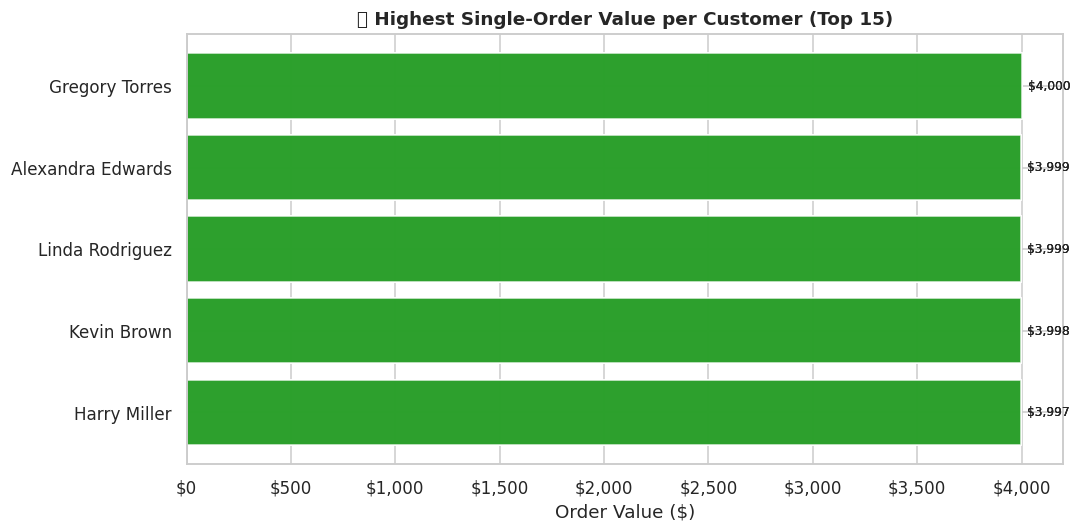

,customer_name,segment,order_id,order_date,highest_order_value
0,Gregory Torres,Corporate,US-2015-139487,2015-03-25,"3,999.77"
1,Gregory Torres,Home Office,US-2015-139487,2015-03-25,"3,999.77"
2,Gregory Torres,Consumer,US-2015-139487,2015-03-25,"3,999.77"
3,Alexandra Edwards,Consumer,CA-2017-146094,2017-08-31,"3,999.04"
4,Alexandra Edwards,Corporate,CA-2017-146094,2017-08-31,"3,999.04"
5,Alexandra Edwards,Home Office,CA-2017-146094,2017-08-31,"3,999.04"
6,Linda Rodriguez,Consumer,US-2016-126416,2016-05-28,"3,998.55"
7,Linda Rodriguez,Corporate,US-2016-126416,2016-05-28,"3,998.55"
8,Linda Rodriguez,Home Office,US-2016-126416,2016-05-28,"3,998.55"
9,Kevin Brown,Consumer,US-2014-128076,2014-07-22,"3,998.36"


In [ ]:
mini5 = """
WITH order_totals AS (
    -- Sum all line-items within the same order
    SELECT
        customer_id,
        order_id,
        order_date,
        ROUND(SUM(sales), 2) AS order_value
    FROM superstore_raw
    GROUP BY customer_id, order_id, order_date
),
ranked_orders AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id
            ORDER BY order_value DESC
        ) AS rn                          -- ← row 1 = highest order per customer
    FROM order_totals
)
SELECT
    c.customer_name,
    c.segment,
    ro.order_id,
    ro.order_date,
    ro.order_value AS highest_order_value
FROM ranked_orders ro
JOIN customers c USING (customer_id)
WHERE ro.rn = 1                          -- ← keep only the best order
ORDER BY ro.order_value DESC
LIMIT 15
"""
df_mini5 = pd.read_sql(mini5, conn)

fig, ax = plt.subplots(figsize=(10, 5))
top15 = df_mini5.head(15)
bars = ax.barh(top15["customer_name"][::-1], top15["highest_order_value"][::-1],
               color="#2ca02c", alpha=0.82)
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in top15["highest_order_value"][::-1]],
             padding=4, fontsize=8)
ax.set_title("💰 Highest Single-Order Value per Customer (Top 15)", fontweight="bold")
ax.set_xlabel("Order Value ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout(); plt.show()

df_mini5

---
##  Summary & Insights

### SQL Techniques Used

| Technique | Where Applied |
|-----------|---------------|
| **Scalar Subquery** (`WHERE sales > (SELECT AVG…)`) | Query 1 — filter above-average orders |
| **Row-value Subquery** (`WHERE (id, sales) IN (SELECT id, MAX…)`) | Query 2 — highest order per customer |
| **CTE** (`WITH … AS`) | Queries 3, 4, 5, 7 — reusable aggregation |
| **CTE + Subquery** | Query 4 — above-average customer sales |
| **`RANK()`** | Query 5, Final, Mini 1 & 2 — tie-aware global rank |
| **`ROW_NUMBER() OVER (PARTITION BY …)`** | Query 6, Mini 5 — per-customer order numbering |
| **`DENSE_RANK()`** | Query 7 — top-3 with no rank gaps |
| **`SUM() OVER ()`** | Final query — % of total sales |
| **Chained CTEs** | Final query — metrics CTE → ranked CTE |
| **JOIN + CTE + Window** | Final query — all three in one statement |

### Business Findings

| Finding | Action |
|---------|--------|
| Top 5 customers generate outsized revenue | Dedicate account managers, loyalty perks |
| Bottom 5 customers have very low spend | Re-engagement campaigns or segment out |
| Customers with exactly 1 order | Win-back emails / first-repeat-purchase discount |
| ~50% of customers are above-average spenders | Those below average need nurturing funnels |
| Highest order values are in Technology | Bundle deals to push basket size in other categories |


In [ ]:
# Close the connection
conn.close()
print("✅ All queries complete — notebook finished.")

✅ All queries complete — notebook finished.
